<a href="https://colab.research.google.com/github/Hibashanti/Time-Series-Analysis/blob/main/Chicago_Crimes_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chicago Crime Data

- Author : Hiba Shanti

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
!pip install holidays
import holidays
import datetime as dt
from holidays import country_holidays
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as tsa
!pip install pmdarima
from pmdarima.arima import nsdiffs, ndiffs
from pmdarima.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 29.8 MB/s eta 0:00:00


# Load the Data
- Integrating multiple years of Chicago Crime files into one dataset.  

In [4]:
folder_path = "/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/Time Series Data/Data/Data"
files = os.listdir(folder_path)

print(files)  # to confirm your files

['Chicago-Crime_2001.csv', 'Chicago-Crime_2002.csv', 'Chicago-Crime_2003.csv', 'Chicago-Crime_2004.csv', 'Chicago-Crime_2005.csv', 'Chicago-Crime_2006.csv', 'Chicago-Crime_2007.csv', 'Chicago-Crime_2009.csv', 'Chicago-Crime_2008.csv', 'Chicago-Crime_2010.csv', 'Chicago-Crime_2012.csv', 'Chicago-Crime_2011.csv', 'Chicago-Crime_2013.csv', 'Chicago-Crime_2015.csv', 'Chicago-Crime_2014.csv', 'Chicago-Crime_2016.csv', 'Chicago-Crime_2017.csv', 'Chicago-Crime_2020.csv', 'Chicago-Crime_2019.csv', 'Chicago-Crime_2018.csv', 'Chicago-Crime_2021.csv', 'Chicago-Crime_2022.csv', 'README.txt', 'example_time_series.csv']


In [5]:
df_list = []

for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_path)
        df_list.append(df_temp)

# Combine all dataframes
df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

(7713309, 18)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
0,1326041.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
1,1319931.0,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2,1324743.0,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
3,1310717.0,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
4,1318099.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convert the datt column to a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df=df.set_index('Date')
df=df.drop(columns="ID")
df.head()

,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
Date,,,,,,,,,,,,,,,,
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


## Topic 1) Comparing Police Districts


##### Which district had the most crimes in 2022?


In [7]:
#1- Calculate the number of crimes for each district yearly
crimes=df.groupby("District").resample("YE").size()
crimes

District  Date      
1.0       2001-12-31    14861
          2002-12-31    17974
          2003-12-31    17571
          2004-12-31    17579
          2005-12-31    17700
                        ...  
31.0      2018-12-31       11
          2019-12-31        7
          2020-12-31        4
          2021-12-31       15
          2022-12-31       15
Length: 507, dtype: int64

In [8]:
# 2- Get the crimes for all discrits in 2022
crimes_22=crimes.loc[(slice (None), "2022")]
crimes_22

,0
District,
1.0,13044
2.0,11793
3.0,11937
4.0,13931
5.0,9773
6.0,14694
7.0,10319
8.0,14805
9.0,10376


In [9]:
# Defining Districs with most crimes in 2022
most_crimes_22_number=crimes_22.max()
most_crimes_22_name=crimes_22.idxmax()
print(f"max crime number in 2022 is {most_crimes_22_number},in {most_crimes_22_name} discrit")

max crime number in 2022 is 14805,in 8.0 discrit


#Which District had the least number of crimes?


In [10]:
# Defining Districs with most crimes in 2022

least_crimes_22_number=crimes_22.min()
least_crimes_22_name=crimes_22.idxmin()
print(f"min crime number in 2022 is {least_crimes_22_number},in {least_crimes_22_name} discrit")


min crime number in 2022 is 15,in 31.0 discrit


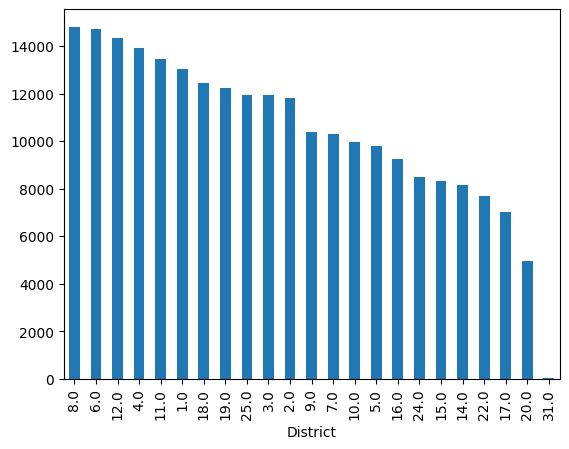

In [11]:
# Visualize the ordered discrits in terms of crime numbers in 2022.
crimes_order=crimes_22.sort_values(ascending=False)
ax=crimes_order.plot(kind="bar")

## Topic 2) Crimes Across the Years:

Text(0, 0.5, 'Number of Crimes')

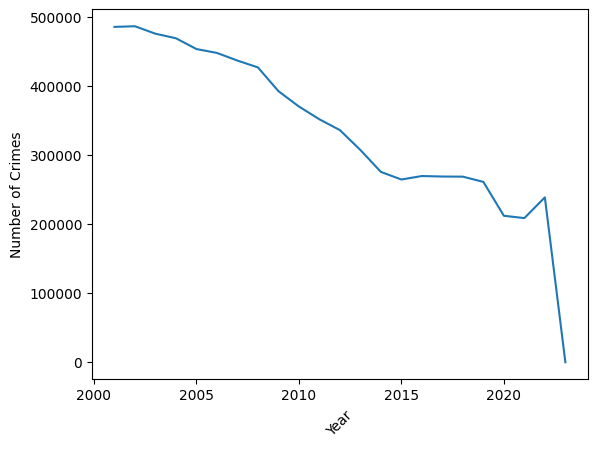

In [12]:
#Is the total number of crimes increasing or decreasing across the years
crimes_trend=df.resample("YE").size()

fig,ax=plt.subplots()
sns.lineplot(x=crimes_trend.index.year, y=crimes_trend.values,ax=ax);
ax.set_xlabel("Year",rotation=45)
ax.set_ylabel("Number of Crimes")


#Chicago crimes have generally decreased over time,with a slight fluctuation.
#The sharp drop in crimes after 2023 is due to incomplete or missing data for the most recent year, not an actual decline.


In [13]:
#Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?
# 1- define the individual crimes during the years
time_bucket=pd.Grouper(freq="YE")
individual_crimes=df.groupby(["Primary Type", time_bucket]).size()

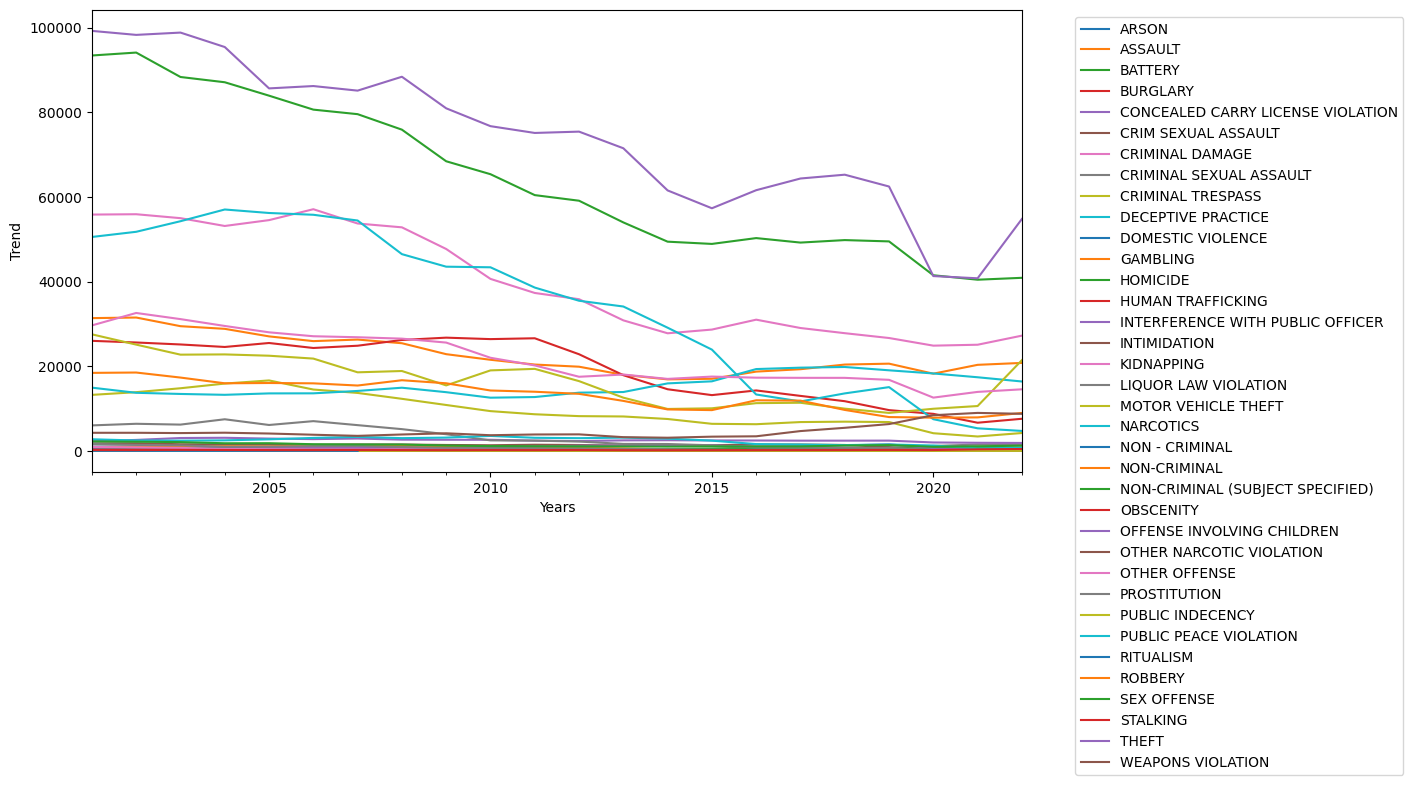

In [14]:
# Visualize the individual crimes during the years
unstacked=individual_crimes.unstack(level=0)
individual_trend=unstacked.plot(figsize=(12,6))
individual_trend.set_xlabel("Years")
individual_trend.set_ylabel("Trend")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left");


# Topic 3) Comparing AM vs. PM Rush Hour:


- Are crimes more common during AM rush hour or PM rush hour?
  - You can consider any crime that occurred between 7 AM - 10 AM as AM rush hour
  - You can consider any crime that occurred between 4 - 7 PM as PM rush hour.

In [15]:
# 1-Define new column for the Hours in the dataset
df["Hour"]=df.index.hour
df["Hour"]

,Hour
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,13
2001-01-01 13:00:00,13
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,0
2023-10-08 00:00:00,0
2023-10-15 00:00:00,0


In [16]:
# 2-Identify each rushing hour group
am_rush=df[(df["Hour"] >= 7) & (df["Hour"]<= 10)]
pm_rush=df[(df["Hour"] >= 16) & (df["Hour"]<=19)]

In [17]:
# 3-Address the length of each group
am_count=len(am_rush)
pm_count=len(pm_rush)

print(f'The Number of crimes in AM rush hour = {am_count}, and in PM rush hour = {pm_count}')

The Number of crimes in AM rush hour = 1097647, and in PM rush hour = 1641051


- Crimes are more common to occure during PM rush hour with a total number of 1,641,051 compared with a total of 1,097,647 in AM rush hour.


In [18]:
#What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?
top_5_am=am_rush["Primary Type"].value_counts()
top_5_am.head(5)

,count
Primary Type,
THEFT,260759
BATTERY,158475
CRIMINAL DAMAGE,109089
BURGLARY,96219
OTHER OFFENSE,89870


In [19]:
#What are the top 5 most common crimes during PM rush hour?
top_5_pm=pm_rush["Primary Type"].value_counts()
top_5_pm.head(5)

,count
Primary Type,
THEFT,379122
BATTERY,288003
CRIMINAL DAMAGE,183423
NARCOTICS,164754
ASSAULT,118179


In [20]:
#Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?
# specify the Motor Vehicle Thefts
mvt_am=am_rush[am_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]
mvt_pm=pm_rush[pm_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]

In [21]:
# Define the length of each period
mvt_am_count=len(mvt_am)
mvt_pm_count=len(mvt_pm)
print(f' number of Motor Vehicle Thefts in AM rush hour= {mvt_am_count},number of Motor Vehicle Thefts in PM rush hour= {mvt_pm_count}')

 number of Motor Vehicle Thefts in AM rush hour= 54035,number of Motor Vehicle Thefts in PM rush hour= 74678


- The number of Motor Vehicle Thefts is more common in the PM rush hour.

 # 4) Comparing Months:


In [22]:
# Adding a Month column to the dataset
df["Month"]=df.index.month
df["Month"]

,Month
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,1
2001-01-01 13:00:00,1
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,10
2023-10-08 00:00:00,10
2023-10-15 00:00:00,10


In [23]:
# What months have the most crime? What months have the least?
monthly_count=df["Month"].value_counts()
most_month=monthly_count.idxmax()
least_month=monthly_count.idxmin()
print(f'the months with the most crime is {most_month}, and the month with the least is {least_month} ')

the months with the most crime is 7, and the month with the least is 2 


In [24]:
#Are there any individual crimes that do not follow this pattern? If so, which crimes?
monthly_crimes=df.groupby(["Primary Type", "Month"]).size()

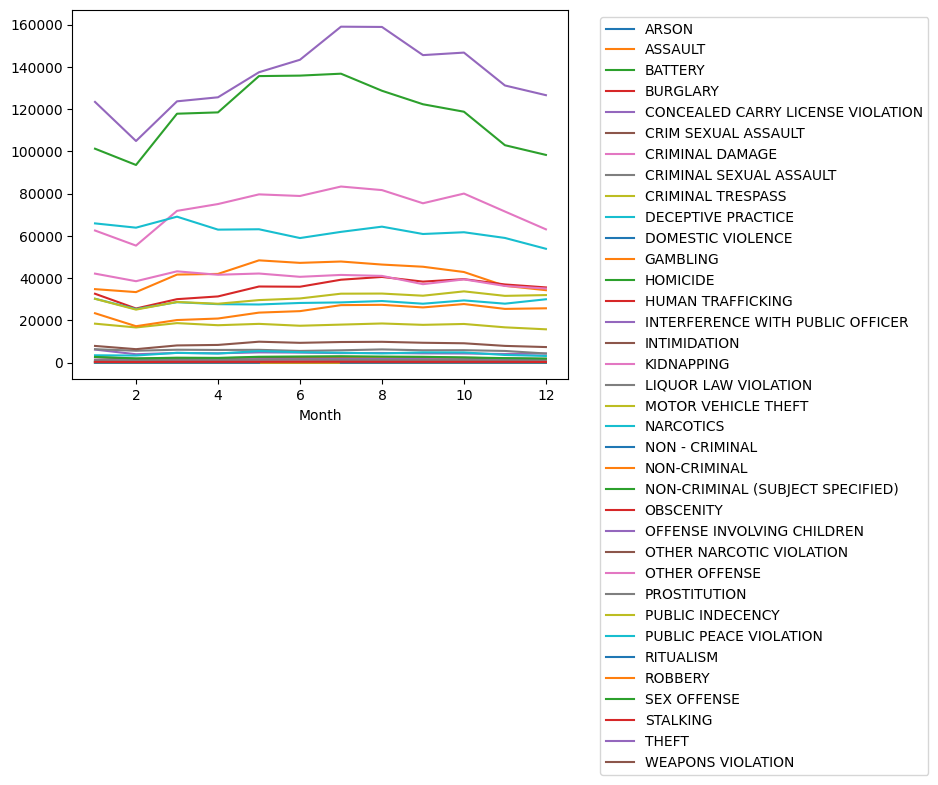

In [25]:
# Visualize the data for each crime during the months
unstacked=monthly_crimes.unstack(level=0)
unstacked.plot()
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left");

In [26]:
# to find the peak for each month,
peak_per_month=unstacked.idxmax()
peak_per_month

,0
Primary Type,
ARSON,7
ASSAULT,5
BATTERY,7
BURGLARY,8
CONCEALED CARRY LICENSE VIOLATION,9
CRIM SEXUAL ASSAULT,7
CRIMINAL DAMAGE,7
CRIMINAL SEXUAL ASSAULT,7
CRIMINAL TRESPASS,3


In [27]:
# to find the least point for each month,
least_per_month=unstacked.idxmin()
least_per_month

,0
Primary Type,
ARSON,2
ASSAULT,2
BATTERY,2
BURGLARY,2
CONCEALED CARRY LICENSE VIOLATION,1
CRIM SEXUAL ASSAULT,12
CRIMINAL DAMAGE,2
CRIMINAL SEXUAL ASSAULT,2
CRIMINAL TRESPASS,12


5) Comparing Holidays:

In [28]:
# Define the holidays in Chicago
Chicago_Holiday=country_holidays("US", subdiv="IL") # Chicago is located in Illinois
Chicago_Holiday

holidays.country_holidays('US', subdiv='IL')

In [29]:
#Get Checago holidays in a column
df["Holiday"]= [Chicago_Holiday.get(day)for day in df.index]
df["Holiday"]

,Holiday
Date,
2001-01-01 01:00:00,New Year's Day
2001-01-01 13:00:00,New Year's Day
2001-01-01 13:00:00,New Year's Day
2001-01-01 01:00:00,New Year's Day
2001-01-01 01:00:00,New Year's Day
...,...
2023-10-01 00:00:00,None
2023-10-08 00:00:00,None
2023-10-15 00:00:00,None


In [30]:
#What are the top 3 holidays with the largest number of crimes?
df["Holiday"].value_counts(ascending=False)


,count
Holiday,
New Year's Day,32726
Independence Day,22673
Labor Day,22164
Memorial Day,21125
Columbus Day,20920
Veterans Day,20418
Casimir Pulaski Day,19128
Lincoln's Birthday,18166
Martin Luther King Jr. Day,17916


In [31]:
#Loop through the 3 holidays with the largest number of crimes, and get the 5 most common crimes on each.
holidays_name=["New Year's Day","Independence Day", "Labor Day"] # Idnntified the holiday list
top_3=df[df["Holiday"].isin(holidays_name)]             # Make the rows only that contain the holiday names from the list
for holiday in holidays_name :
   holiday_count=top_3[top_3["Holiday"]== holiday]       # defined that the loop goes through each holiday name
   top_5_crimes=holiday_count["Primary Type"].value_counts().head(5) # count the top 5 crimes in each holiday
   print(f'{holiday},has the following 5 crimes{top_5_crimes}')



New Year's Day,has the following 5 crimesPrimary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64
Independence Day,has the following 5 crimesPrimary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64
Labor Day,has the following 5 crimesPrimary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64


#6) What cycles (seasonality) can you find in this data?
 - Select the "OFFENSE INVOLVING CHILDREN" - Monthly

In [32]:
# Resample the OFFENSE INVOLVING CHILDREN crime monthly
oic=df[df["Primary Type"] == "OFFENSE INVOLVING CHILDREN"]
oic_monthly=oic.resample("ME").size()

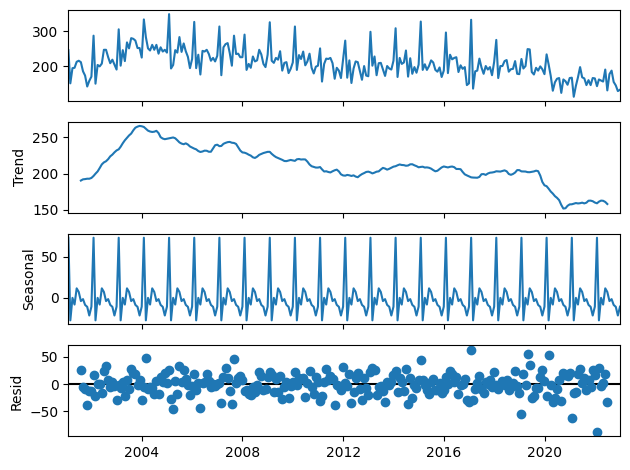

In [33]:
# Check for seasonality in the data
decompose=tsa.seasonal_decompose(oic_monthly)
fig=decompose.plot()

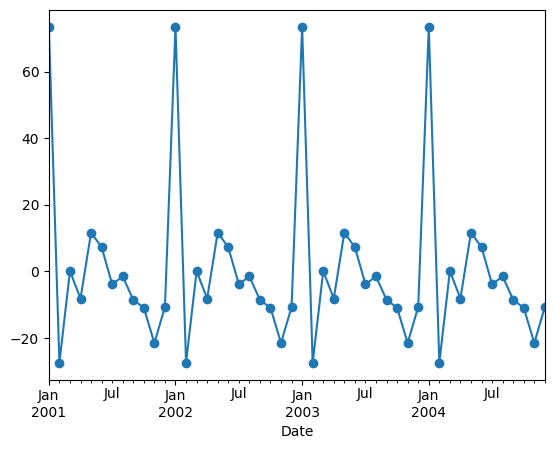

In [34]:
ax=decompose.seasonal.loc[:"2004"].plot(marker="o")

- From the graph above, we can see that the OFFENSE INVOLVING CHILDREN crime data has seasonality, and the seasonal cycle is one year, which means that this crime occurs more often in certain times. When we zoom in on the seasonal graph, we see that the number of OFFENSE INVOLVING CHILDREN crimes increases in January and is followed by a significant decrease in February.

- The January increase in “OFFENSE INVOLVING CHILDREN” may be caused by post-holiday reporting, school reopening, and increased family stress during the winter season. The decrease in February may occur because February has fewer days and reporting levels return to normal.

# Part 2 : WE Will be helping Chicago law enforcement allocate resources for the next 6 months For the "Theft" and "Battery" crimes.

In [35]:
# Starting with the Theft Crime. Transform the data into monthly data.
Theft_monthly=df[df["Primary Type"] == "THEFT"].resample("ME").size()

In [36]:
#Check for null values
Theft_monthly.isna().sum().sum()

np.int64(0)

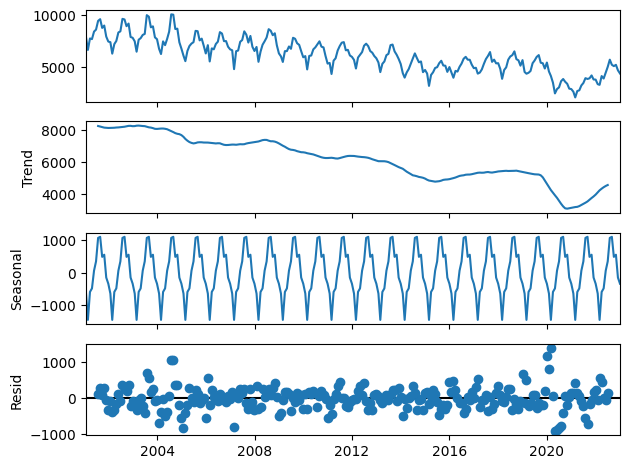

In [37]:
#Decompose the Time series to detect seasonality and decide whether to use a seasonal model or not
decompose_2=tsa.seasonal_decompose(Theft_monthly)
fig=decompose_2.plot()

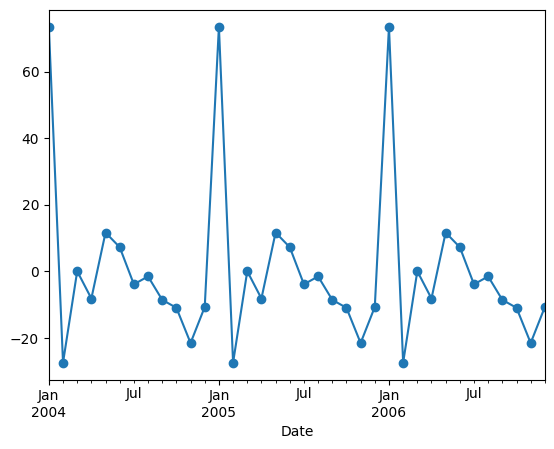

In [38]:
# Determine the seasonality period
ax=decompose.seasonal.loc["2004":"2006"].plot(marker="o")
# The seasonality period is one year.

In [39]:
#Check for stationarity: Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
   # Saving each output
   (test_stat, pval, nlags, nobs, crit_vals_d,icbest ) = tsa.adfuller(ts, **kwargs)
   # Converting output to a dictionary with the interpretation of p
   adfuller_results = {'Test Statistic': test_stat,
                       "# of Lags Used":nlags,
                      '# of Observations':nobs,
                       'p-value': round(pval,6),
                       'alpha': alpha,
                      'sig/stationary?': pval < alpha}
   return pd.DataFrame(adfuller_results, index =[label])

In [40]:
get_adfuller_results(Theft_monthly)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.393935,13,250,0.58518,0.05,False


In [41]:
# Check for the number of differences required to eliminate seasonality and trend from the data:
regular_diff=ndiffs(Theft_monthly)
seasonal_diff=nsdiffs(Theft_monthly, m=12)
print(f'd= {regular_diff},and D= {seasonal_diff}' )

d= 1,and D= 0


In [42]:
theft_m_diff=Theft_monthly.diff().dropna()
# Confirm the stationarity
get_adfuller_results(theft_m_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-3.953728,12,250,0.001673,0.05,True


In [43]:
 def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),annotate_sig=False, alpha=.05,acf_kws={}, pacf_kws={}, annotate_seas=False, m = None,seas_color='black'):
   fig, axes = plt.subplots(nrows=2, figsize=figsize)
   # Sig lags line style
   sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
   # ACF
   tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)
    ## Annotating sig acf lags
   if annotate_sig == True:
       sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
       for lag in sig_acf_lags:
           axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
   # PACF
   tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)
     ## Annotating sig pacf lags
   if annotate_sig == True:
       ## ANNOTATING SIG LAGS
       sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
       for lag in sig_pacf_lags:
           axes[1].axvline(lag, label='sig', **sig_vline_kwargs)
    ### ANNOTATE SEASONS
   if annotate_seas == True:
       # Ensure m was defined
       if m is None:
           raise Exception("Must define value of m if annotate_seas=True.")
       ## Calculate number of complete seasons to annotate
       n_seasons = nlags//m
       # Seasonal Lines style
       seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)
     ## for each season, add a line
       for i in range(1, n_seasons+1):
           axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
           axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
   fig.tight_layout()
   plt.close(fig)
   return fig

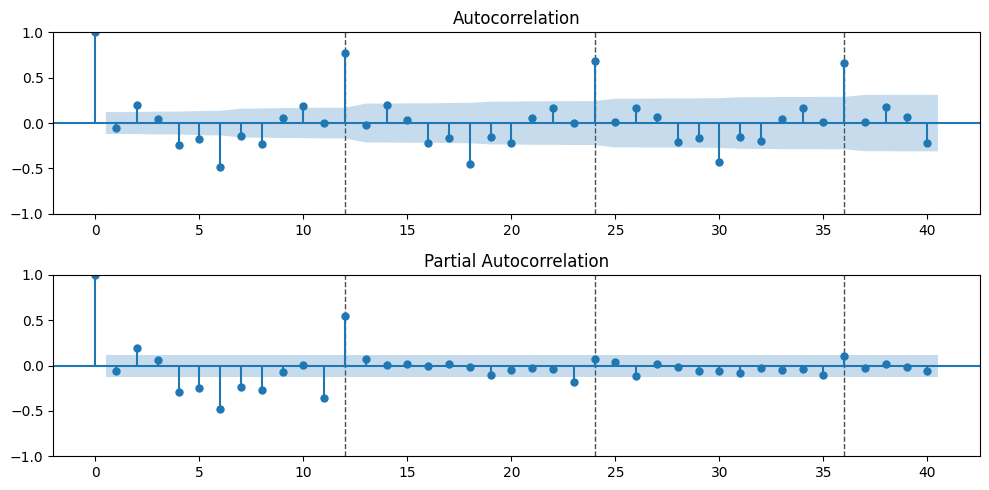

In [44]:
#Use the ACF and PACF plots of stationarity data to estimate initial orders
plot_acf_pacf(theft_m_diff,m=12, annotate_seas=True)

- For the regular lags: p=1, d=1, q=1
- For the seasonal lags: P=1, D=0, Q=1, m-12
- Since the data are seasonal, we will be using the ASIRMA model

In [45]:
#Split the time series into training and test data (Remember we want to predict 6 months)
test_size=6
train,test=train_test_split(Theft_monthly, test_size=test_size)

In [53]:
#Fit a manual ARIMA/SARIMA model based on the orders determined during your exploration.
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
p=1
d=1
q=1
P=1
D=0
Q=1
m=12
sarima=tsa.ARIMA(train,order=(p,d,q),seasonal_order=(P,D,Q,m)).fit()

In [47]:
#Make forecasts with your model.
sarima_forcast=sarima.get_forecast(len(test)).summary_frame()
sarima_forcast

y,mean,mean_se,mean_ci_lower,mean_ci_upper
2022-07-31,5440.048282,333.287913,4786.815976,6093.280587
2022-08-31,5542.837069,471.328521,4619.050143,6466.623995
2022-09-30,5236.920521,577.242789,4105.545443,6368.295598
2022-10-31,5271.930436,666.525945,3965.563588,6578.297283
2022-11-30,4854.246561,745.180100,3393.720404,6314.772718
2022-12-31,4955.387405,816.283582,3355.500983,6555.273826


In [48]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None, figsize=(10,4),   title='Comparing Forecast vs. True Data'):
   ### PLot training data, and forecast (with upper/,lower ci)
   fig, ax = plt.subplots(figsize=figsize)
   # setting the number of train lags to plot if not specified
   if n_train_lags==None:
       n_train_lags = len(ts_train)
   # Plotting Training  and test data
   ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
   ts_test.plot(label="test", ax=ax)
   # Plot forecast
   forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
   # Add the shaded confidence interval
   ax.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'],color='green', alpha=0.3,  lw=2)
   ax.set_title(title)
   ax.legend();
   return fig, ax

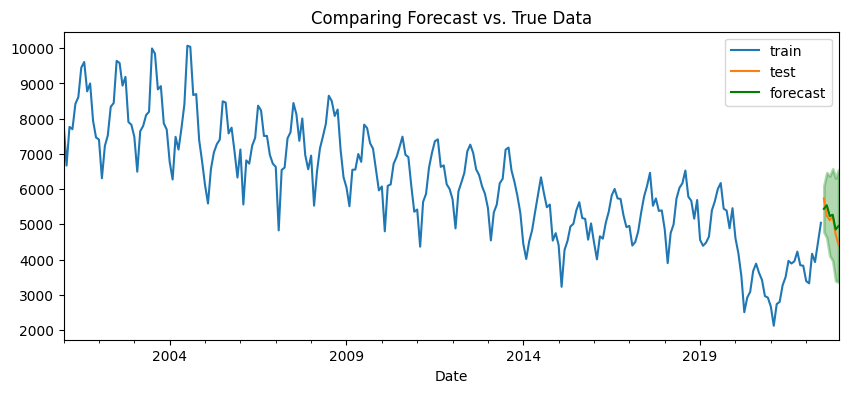

In [49]:
#Plot the forecasts versus the test data
plot_forecast(train,test,sarima_forcast);

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
   # Get metrics
   mae = mean_absolute_error(ts_true, ts_pred)
   mse = mean_squared_error(ts_true, ts_pred)
   rmse = np.sqrt(mse)
   r_squared = r2_score(ts_true, ts_pred)
   mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100
   if verbose == True:
       # Print Result with label
       header = "---" * 20
       print(header, f"Regression Metrics: {label}", header, sep="\n")
       print(f"- MAE = {mae:,.3f}")
       print(f"- MSE = {mse:,.3f}")
       print(f"- RMSE = {rmse:,.3f}")
       print(f"- R^2 = {r_squared:,.3f}")
       print(f"- MAPE = {mae_perc:,.2f}%")
   if output_dict == True:
       metrics = {
           "Label": label,
           "MAE": mae,
           "MSE": mse,
           "RMSE": rmse,
           "R^2": r_squared,
           "MAPE(%)": mae_perc,}
       return metrics

In [51]:
#Obtain metrics for evaluation
regression_metrics_ts(test,sarima_forcast['mean'])

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 237.046
- MSE = 84,001.447
- RMSE = 289.830
- R^2 = 0.524
- MAPE = 4.82%


In [62]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1874.315
Date:                          Tue, 12 May 2026   AIC                           3758.631
Time:                                  17:59:31   BIC                           3776.376
Sample:                              01-31-2001   HQIC                          3765.767
                                   - 06-30-2022                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9989      1.584      0.631      0.528      -2.105       4.103
ma.L1         -0.9989      1.532     -0.652      0.514      -4.002       2.004
ar.S.L12       0.9710      0.009    111.409      0.000       0.954       0.988
ma.S.L12      -0.6637      0.044    -15.002      0.000      -0.750      -0.577
sigma2      1.111e+05   8533.175     13.018      0.000    9.44e+04    1.28e+05
===================================================================================
Ljung-Box (L1) (Q):                  11.00   Jarque-Bera (JB):                12.55
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.70   Skew:                            -0.25
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

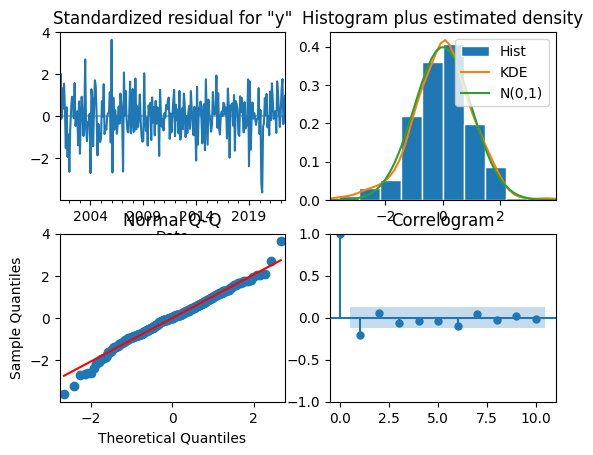

In [54]:
# Display the dignositics of the data
fig=sarima.plot_diagnostics()

- The model is performing well, from the metrics above, we see that the MAPE result is excellent(4.82%), it means that the predictions are off by less than %5 on average.

- Also, in the correlgram plot, almost all points are within the shaded area, this indicates that the model has successfully captured almost all the patterns in the data.

- However, when comparing the testing and forecasting data, the forecast is slightly "stiff." It captures the downward slope but doesn't quite match the sharpness of the dips in the test data. Therefore, we might tune the model to make some improvenmnts.

Tune with pmdarima's auto_arima


In [57]:
import pmdarima as pm
auto_model=pm.auto_arima(train, seasonal =True, m=12,trace=True)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=6.74 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=0.47 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=1.21 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3743.851, Time=3.42 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=2.27 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=5.40 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.901, Time=3.25 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=1.29 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=0.41 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=2.44 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

In [59]:
# Fit the tuned model with the new parameters
p=1
d=1
q=0
P=1
D=0
Q=2
m=12
sarima_2=tsa.ARIMA(train,order=(p,d,q),seasonal_order=(P,D,Q,m)).fit()

In [63]:
sarima_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                       
=============================================================================================
Dep. Variable:                                     y   No. Observations:                  258
Model:             ARIMA(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1865.634
Date:                               Tue, 12 May 2026   AIC                           3741.268
Time:                                       18:00:23   BIC                           3759.013
Sample:                                   01-31-2001   HQIC                          3748.404
                                        - 06-30-2022                                         
Covariance Type:                                 opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2251      0.046     -4.934      0.000      -0.315      -0.136
ar.S.L12       0.9778      0.008    120.055      0.000       0.962       0.994
ma.S.L12      -0.5771      0.059     -9.815      0.000      -0.692      -0.462
ma.S.L24      -0.1202      0.068     -1.758      0.079      -0.254       0.014
sigma2      1.038e+05   7353.336     14.120      0.000    8.94e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                30.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.44
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [65]:
#Get the forecasts for the nex 6 months
forecast_2=sarima_2.get_forecast(len(test)).summary_frame()
forecast_2

y,mean,mean_se,mean_ci_lower,mean_ci_upper
2022-07-31,5377.704997,322.225632,4746.154364,6009.255630
2022-08-31,5459.157428,407.647190,4660.183616,6258.131239
2022-09-30,5179.754130,486.767957,4225.706465,6133.801794
2022-10-31,5261.200531,552.962979,4177.413008,6344.988055
2022-11-30,4835.268634,612.395139,3634.996218,6035.541050
2022-12-31,4908.275139,666.475489,3602.007184,6214.543094


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Comparing Forecast vs. True Data'}, xlabel='Date'>)

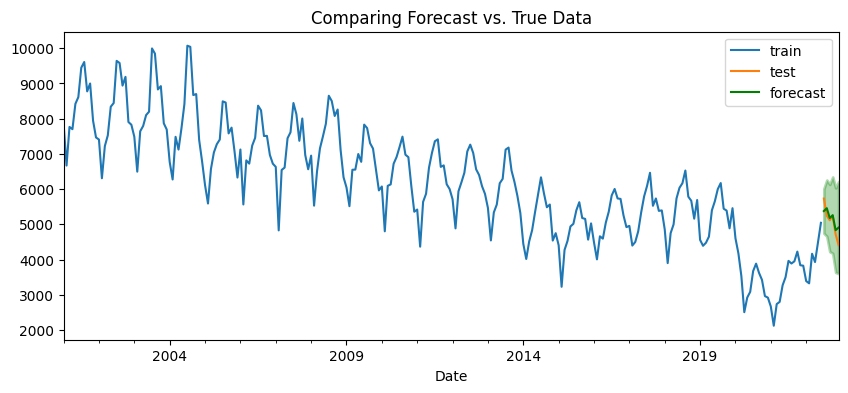

In [66]:
# Plot the forecastes
plot_forecast(train,test,forecast_2)

In [67]:
# The regression metrics for the tuned model
regression_metrics_ts(test,forecast_2["mean"])

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 211.158
- MSE = 72,805.087
- RMSE = 269.824
- R^2 = 0.587
- MAPE = 4.27%


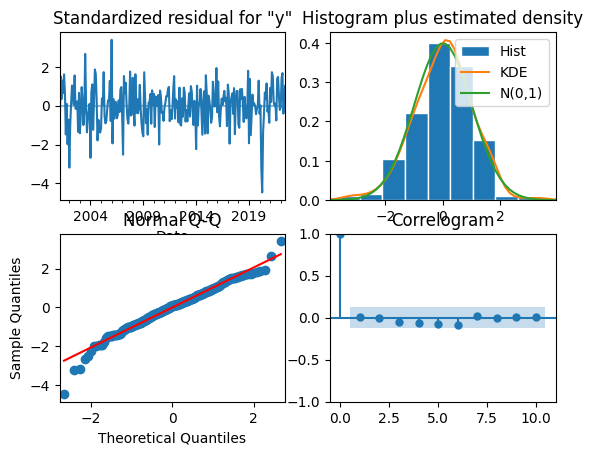

In [68]:
# The diagnostics
ax=sarima_2.plot_diagnostics();

- After tuning the model, the results improved as follows :
  - MAPE result decreased from %4.82 to %4.27, which means the model has improved, and the percentage of wrong predictions decreased.

  - The correlogram, فhe points appear more aligned within the shaded area than in the previous model.

  - In the graph for comparing the forecasted and true data, the green line (forecast) is matching the orange line(true data) slightly more than in the original model, however, it still doesn't quite match the sharpness of the dips in the test data.

  - AIC for the tuned model (3741) is lower than the original model (3758)

In conclusion, we have selected the tuned SARIMA model for our final forecast. This version demonstrated superior predictive accuracy, achieving a MAPE of 4.27% and a more balanced set of residual diagnostics compared to the baseline. By optimizing the hyperparameters, we have successfully minimized the AIC, ensuring the model captures the core seasonal patterns without overfitting.